In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from lisatools.utils.constants import YRSID_SI
from bbhx.waveformbuild import BBHWaveformFD
from antenna_pattern_utils import *

No CuPy


5e-05


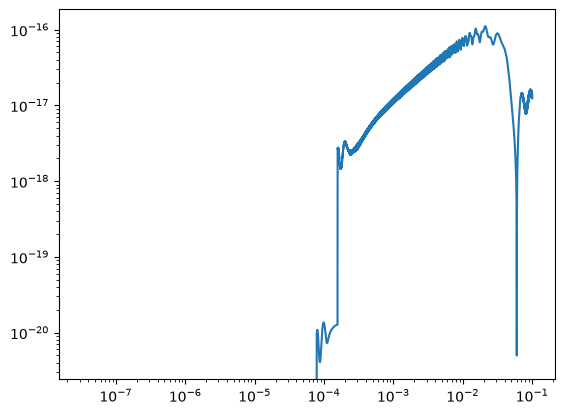

In [20]:
plt.loglog(freq, np.abs(wave_freq_domain[0]), label='A')
#plt.xlim(5e-5, 1)

In [2]:
DAY_SI = 24*3600
Tobs = YRSID_SI
dt = 5.
N = int(Tobs / dt)
Tobs = N * dt
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1] # have to do this as freq[0] = 0 causes issues with the waveform generator
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))


import time
t_start = time.time()

m1 = 1e5
m2 = 2e5
chi1z = 0.0
chi2z = 0.7
dist = 2 * 1e9 * PC_SI
phi_ref = 1.0
f_ref = 0.0
inc = 2*np.pi/3  #2*np.pi/3.
lam = 0
beta= 0
psi = 3*np.pi/8
t_c = Tobs - 5*DAY_SI # chose to have the merger at 5 days before the end of the observation time

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_c, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]
t_1 = time.time()
print("Time taken for waveform generation: ", t_1 - t_start, " seconds")

wave_time_domain = sp.fft.irfft(wave_freq_domain, axis=-1)
t_2 = time.time()
print("Time taken for waveform to time domain: ", t_2 - t_1, " seconds")

nperseg = 60*60*24/dt  # 1 day segments
print("nperseg: ", nperseg)
f, t, Zxx = sp.signal.stft(wave_time_domain,  # 0 is A, 1 is E, 2 is T
                           fs=1/dt, 
                           nperseg=nperseg, 
                           noverlap=nperseg//2
                           )
t_3 = time.time()
print("Time taken for STFT: ", t_3 - t_2, " seconds")


Time taken for waveform generation:  0.9126298427581787  seconds
Time taken for waveform to time domain:  0.34829282760620117  seconds
nperseg:  17280.0
Time taken for STFT:  0.128737211227417  seconds


In [5]:
Zxx[2]

array([[ 4.04052201e-28+0.00000000e+00j, -2.12041766e-35+0.00000000e+00j,
        -5.03285729e-36+0.00000000e+00j, ...,
        -1.91715292e-35+0.00000000e+00j, -1.94131277e-28+0.00000000e+00j,
        -2.09920903e-28+0.00000000e+00j],
       [-4.04052219e-28-7.34378175e-32j, -2.19439544e-35-5.74653474e-37j,
        -5.20108360e-36+5.52368061e-36j, ...,
        -1.98580179e-35-1.63306641e-37j, -7.58633004e-30-1.93983000e-28j,
         8.20331765e-30+2.09760582e-28j],
       [ 4.04052283e-28+1.46864091e-31j, -2.42849823e-35-1.19942056e-36j,
        -5.80255508e-36+1.16629502e-35j, ...,
        -2.17406959e-35-3.39168215e-37j,  1.93538405e-28-1.51610702e-29j,
         2.09279843e-28-1.63940835e-29j],
       ...,
       [ 3.75910281e-26+1.46271360e-24j, -3.24014483e-27-3.04716080e-26j,
        -2.49659879e-27-2.56342260e-26j, ...,
        -7.04630156e-27-5.09615739e-26j,  3.21279077e-25+3.22015731e-25j,
        -4.17093739e-25+3.75734592e-25j],
       [-1.72906698e-24-2.14283499e-24j, -3.

(8641,) (732,) (3, 8641, 732)
(8641, 732)
(3, 732)
(3, 8641)


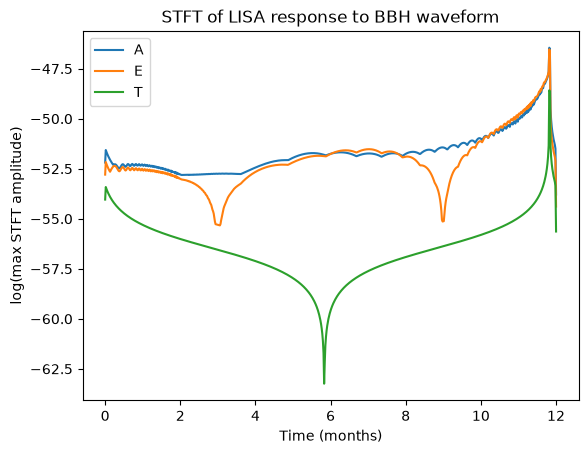

In [3]:
print(f.shape, t.shape, Zxx.shape)
print(np.max(np.abs(Zxx), axis=0).shape)
print(np.max(np.abs(Zxx), axis=1).shape)
print(np.max(np.abs(Zxx), axis=2).shape)

max_zxx = (np.max(np.abs(Zxx), axis=1))

plt.plot(t/ (24*3600)/30.45428241, np.log(max_zxx[0]), label='A')
plt.plot(t/ (24*3600)/30.45428241, np.log(max_zxx[1]), label='E')
plt.plot(t/ (24*3600)/30.45428241, np.log(max_zxx[2]), label='T')
plt.xlabel('Time (months)')
plt.ylabel('log(max STFT amplitude)')
plt.title('STFT of LISA response to BBH waveform')
plt.legend()

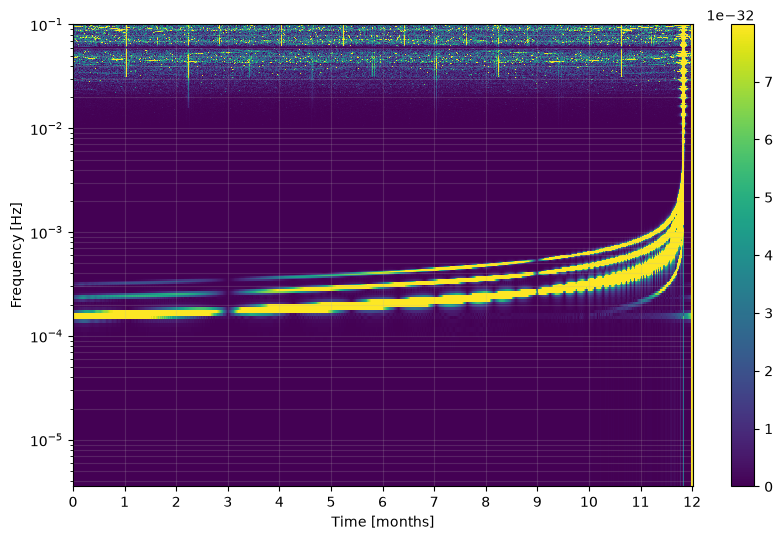

In [11]:
t_months = t/(24*3600)/30.45428241

plt.figure(figsize=(10, 6))
plt.pcolormesh(t_months, f, np.abs(Zxx[2]), vmin=0, vmax= np.max(np.abs(Zxx[2]))/10000000000, cmap='viridis')
plt.grid(True, which='both', alpha=0.2)
plt.xticks(np.arange(0, 13, 1)) 
plt.yscale('log')
plt.ylabel('Frequency [Hz]',)
plt.xlabel('Time [months]',)
plt.colorbar()

I did some testing and I found a few things. The time frequency (stft) domain amplitudes don't really go below 1e-5 Hz. Also, I realized that LISA is only going to be sensitive to gravitational waves between 0.1 mHz and 1 Hz. 

In [84]:
DAY_SI = 24*3600
Tobs = YRSID_SI
dt = 5.
N = int(Tobs / dt)
Tobs = N * dt
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1] # have to do this as freq[0] = 0 causes issues with the waveform generator
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))


import time
t_start = time.time()

m1 = 1e5
m2 = 2e5
chi1z = 0.0
chi2z = 0.7
dist = 2 * 1e9 * PC_SI
phi_ref = 1.0
f_ref = 0.0
inc = 2*np.pi/3  #2*np.pi/3.
lam = 0
beta= 0
psi = 3*np.pi/8
t_c = Tobs - 5*DAY_SI # chose to have the merger at 5 days before the end of the observation time

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_c, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]
t_1 = time.time()
print("Time taken for waveform generation: ", t_1 - t_start, " seconds")

wave_time_domain = sp.fft.irfft(wave_freq_domain[:2], axis=-1)
t_2 = time.time()
print("Time taken for waveform to time domain: ", t_2 - t_1, " seconds")

f, t, Zxx = sp.signal.stft(wave_time_domain[1],  # 0 is A, 1 is E, 2 is T
                           fs=1/dt, nperseg=15000, noverlap=0)
t_3 = time.time()
print("Time taken for STFT: ", t_3 - t_2, " seconds")

max_freq = 0.1
max_freq_idx = np.searchsorted(f, max_freq)
min_freq = 3e-5
min_freq_idx = np.searchsorted(f, min_freq)

t_months = t/(24*3600)/30.45428241

max_zxx = []
for i in range(0, len(Zxx[0])):
    max_zxx.append(np.max(np.abs(Zxx[:,i])))
max_zxx = np.array(max_zxx)/np.max(np.array(max_zxx))
t_4 = time.time()
print("Time taken for max_zxx calculation: ", t_4 - t_3, " seconds")

t_end = time.time()
print("Time taken for everything: ", t_end - t_start, " seconds")

Time taken for waveform generation:  0.917374849319458  seconds
Time taken for waveform to time domain:  0.23592686653137207  seconds
Time taken for STFT:  0.03176999092102051  seconds
Time taken for max_zxx calculation:  0.005340099334716797  seconds
Time taken for everything:  1.190443754196167  seconds


In [89]:
(1.2*100000)//(60*60)

33.0

# Time-Frequency Domain, Noiseless

## Spectrogram

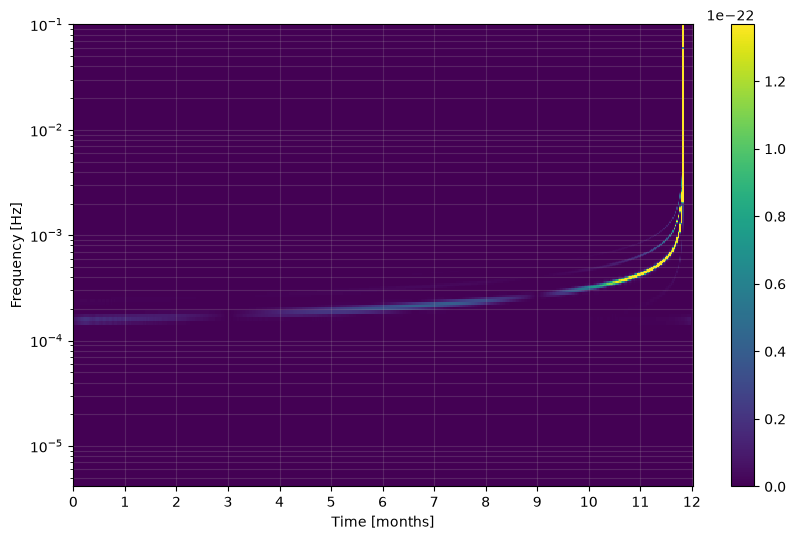

In [4]:
f_stft_noiseless, t_stft_noiseless, zxx_noiseless = sp.signal.stft(wave_time_domain[1], fs=1/dt, nperseg=15000, noverlap=0)         # In wave_time_domain: 0 is A, 1 is E, 2 is T

t_months = t_stft_noiseless/(24*3600)/30.45428241

plt.figure(figsize=(10, 6))
plt.pcolormesh(t_months, f_stft_noiseless, np.abs(zxx_noiseless), vmin=0, vmax= np.max(np.abs(zxx_noiseless))/100, cmap='viridis')
plt.grid(True, which='both', alpha=0.2)
plt.xticks(np.arange(0, 13, 1)) 
plt.yscale('log')
plt.ylabel('Frequency [Hz]',)
plt.xlabel('Time [months]',)
plt.colorbar()

## Maximas per time bin

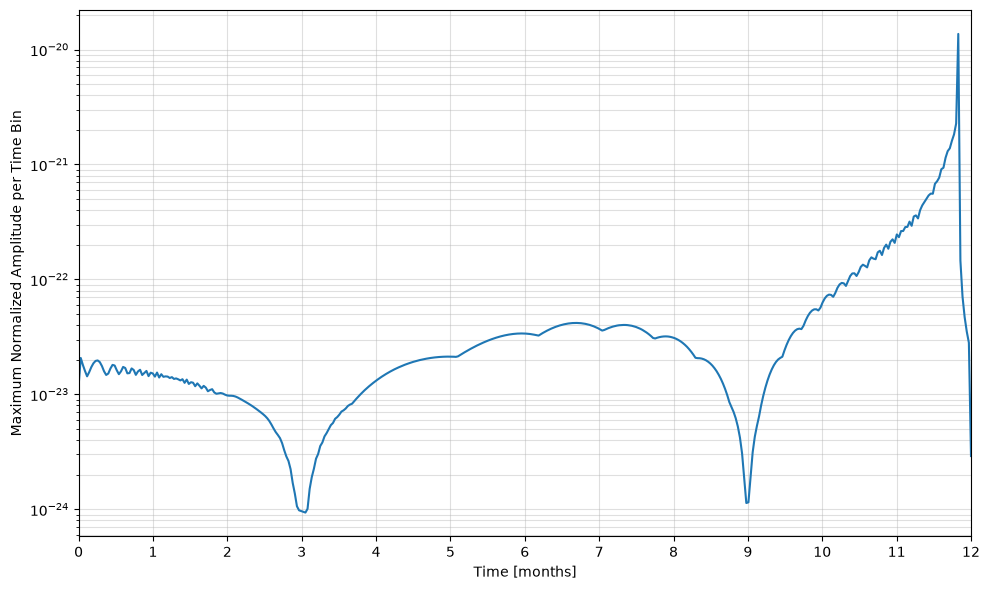

In [5]:
max_zxx = []
max_zxx = np.max(np.abs(zxx_noiseless), axis=0)
#max_zxx_normalized = max_zxx/np.max(np.array(max_zxx))
plt.figure(figsize=(10, 6))

plt.plot(t_months, max_zxx)
plt.ylabel('Maximum Normalized Amplitude per Time Bin')
plt.xlabel('Time [months]')
plt.yscale('log')
plt.grid(True, which='both', alpha=0.4)
plt.xlim(t_months[0], t_months[-1])
plt.xticks(np.arange(0, 13, 1))
plt.tight_layout()
plt.show()

In [51]:
DAY_SI = 24*3600
Tobs = YRSID_SI
dt = 5.
N = int(Tobs / dt)
Tobs = N * dt
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1] # have to do this as freq[0] = 0 causes issues with the waveform generator
wave_gen_22 = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=True))


import time
t_start = time.time()

m1 = 1e5
m2 = 2e5
chi1z = 0.0
chi2z = 0.7
dist = 2 * 1e9 * PC_SI
phi_ref = 1.0
f_ref = 0.0
inc = 2*np.pi/3  #2*np.pi/3.
lam = 0
beta= 0
psi = 3*np.pi/8
t_c = Tobs - 5*DAY_SI # chose to have the merger at 5 days before the end of the observation time

wave_freq_domain_22 = wave_gen_22(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_c, 
                            freqs=freq, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]
t_1 = time.time()
print("Time taken for waveform generation: ", t_1 - t_start, " seconds")

wave_time_domain_22 = np.fft.irfft(wave_freq_domain_22, axis=-1)
t_2 = time.time()
print("Time taken to convert to time domain: ", t_2 - t_1, " seconds")

f_stft_noiseless_22, t_stft_noiseless_22, zxx_noiseless_22 = sp.signal.stft(wave_time_domain_22[1],  # 0 is A, 1 is E, 2 is T
                           fs=1/dt, nperseg=15000, noverlap=0)
t_3 = time.time()
print("Time taken for STFT: ", t_3 - t_2, " seconds")

max_zxx_22 = []
for i in range(0, len(zxx_noiseless_22[0])):
    max_zxx_22.append(np.max(np.abs(zxx_noiseless_22[:,i])))
max_zxx_22 = np.array(max_zxx_22)#/np.max(np.array(max_zxx_22))

t_4 = time.time()
print("Time taken for max_zxx calculation: ", t_4 - t_3, " seconds")

t_end = time.time()
print("Time taken for everything: ", t_end - t_start, " seconds")

Time taken for waveform generation:  0.17169713973999023  seconds
Time taken to convert to time domain:  1.3595399856567383  seconds
Time taken for STFT:  0.039853811264038086  seconds
Time taken for max_zxx calculation:  0.005376100540161133  seconds
Time taken for everything:  1.576498031616211  seconds


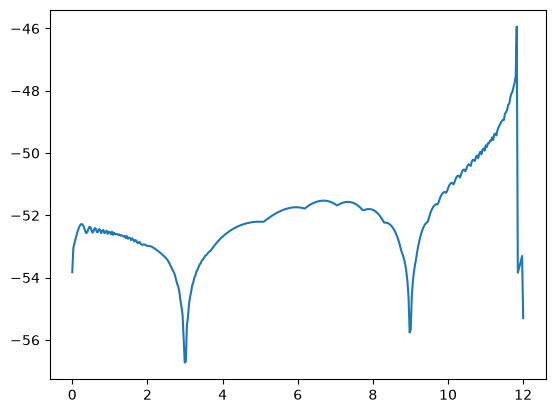

In [53]:
plt.plot(t_stft_noiseless_22/ (24*3600)/30.45428241, np.log(max_zxx_22))


#plt.plot(t_stft_noiseless/ (24*3600)/30.45428241, np.log(max_zxx))


# Test t_ref

Frequency range:  3.168754056995429e-08  to  0.09999998415622972  Hz


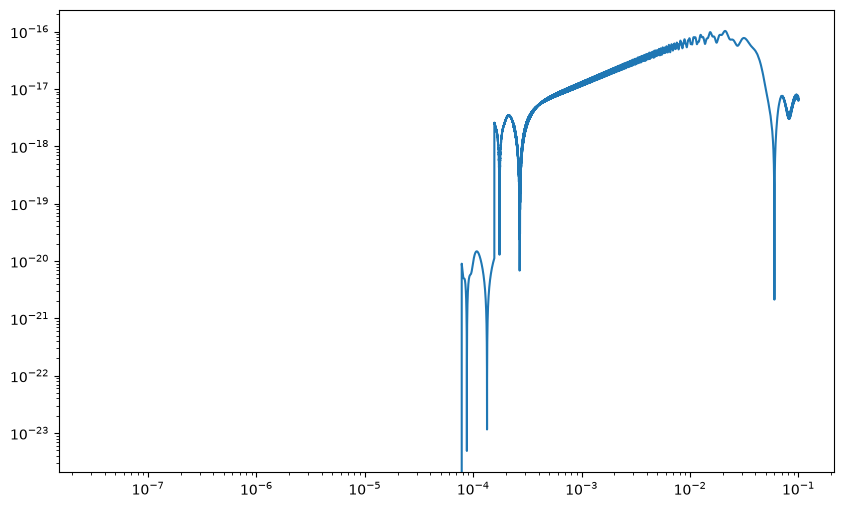

In [100]:
# plot the frequency array freq to see the frequency range
plt.figure(figsize=(10, 6))
plt.plot(freq, np.abs(wave_freq_domain[1]))
plt.xscale('log')
plt.yscale('log')
print("Frequency range: ", freq[0], " to ", freq[-1], " Hz")

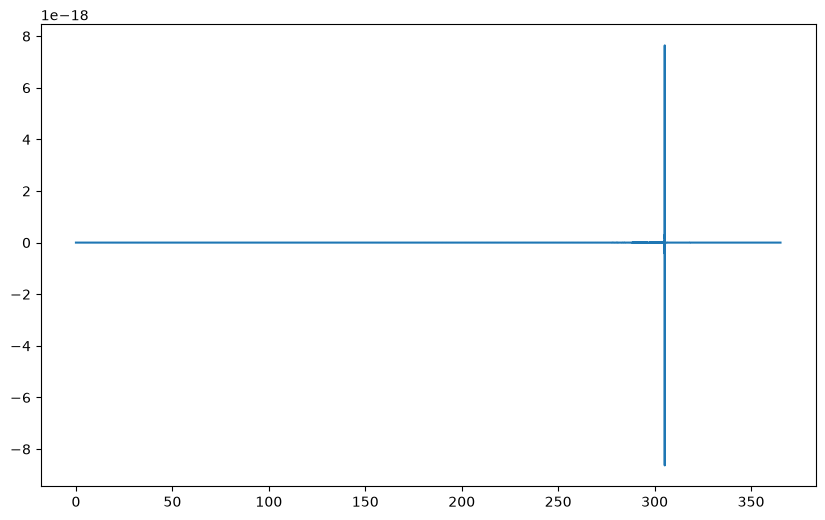

In [110]:
DAY_SI = 24*3600
Tobs = YRSID_SI
dt = 5.
N = int(Tobs / dt)
Tobs = N * dt
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1] # have to do this as freq[0] = 0 causes issues with the waveform generator


wave_gen_test = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))

t_ref = Tobs - 60*DAY_SI # chose to have the merger at 5 days before the end of the observation time

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain_test = wave_gen_test(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_ref, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]
wave_time_domain_test = np.fft.irfft(wave_freq_domain_test, axis=-1)

plt.figure(figsize=(10, 6))
plt.plot((np.arange(0, Tobs, dt)/(24*3600))[0:-1], wave_time_domain_test[1])


In [111]:
freq_band

array([0.00010001, 0.00010004, 0.00010007, ..., 0.09999992, 0.09999995,
       0.09999998], shape=(3152659,))

ValueError: x and y must have same first dimension, but have shapes (3152659,) and (1,)

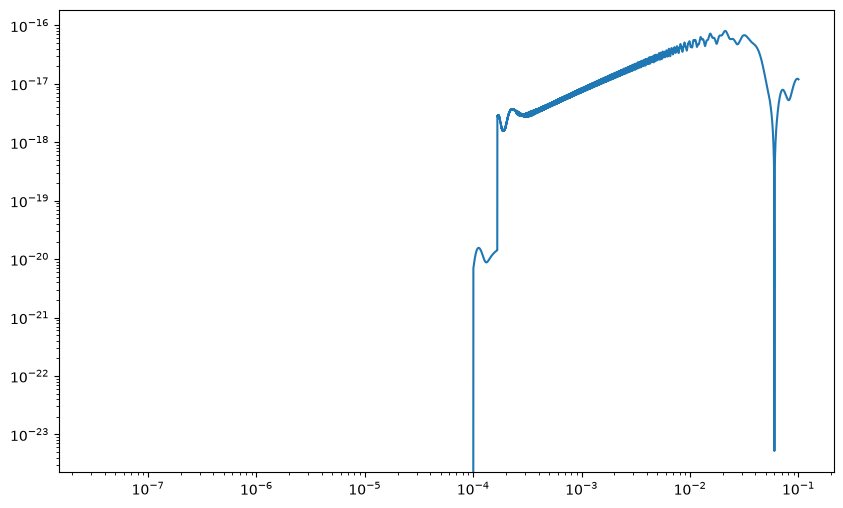

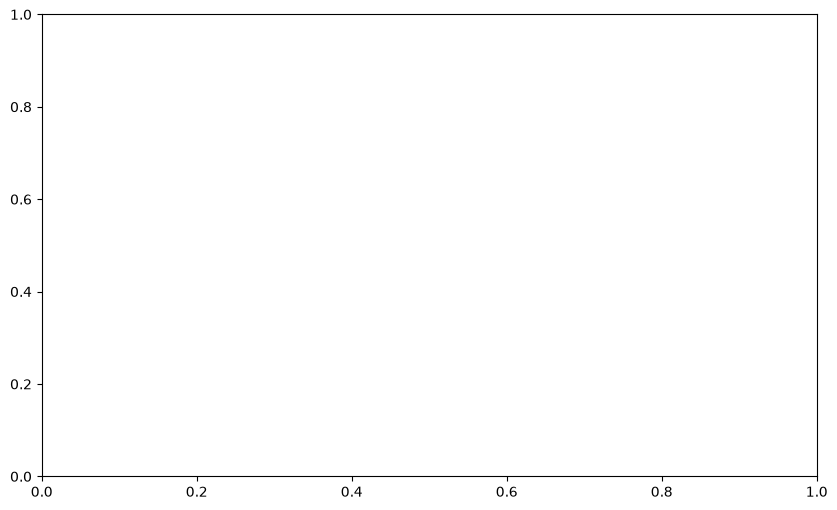

In [114]:
Tobs = YRSID_SI
dt = 5.0
N = int(Tobs / dt)
freq_full = np.fft.rfftfreq(N, dt)          # full grid, needed for irfft bookkeeping

f_min, f_max = 1e-4, 1e-1                    # LISA-sensitive band
band_mask = (freq_full >= f_min) & (freq_full <= f_max)
freq_band = freq_full[band_mask]             # much smaller array to actually compute

wave_band = wave_gen(m1, m2, chi1z, chi2z, dist, phi_ref, f_ref, inc, lam,
                      beta, psi, t_ref, freqs=freq_band,
                      modes=modes, direct=True, fill=True,
                      squeeze=True, length=1024)[0]   # shape (3, len(freq_band))

# embed back into the full-length array, zero elsewhere
wave_full = np.zeros((3, len(freq_full)), dtype=complex)
wave_full[:, band_mask] = wave_band

# time domain
h_t = np.fft.irfft(wave_full, n=N, axis=-1)  # shape (3, N)
t = np.arange(N) * dt

# plot the frequency array freq to see the frequency range
plt.figure(figsize=(10, 6))
plt.plot(freq_full, np.abs(wave_full[1]))
plt.xscale('log')
plt.yscale('log')

# plot the frequency array freq to see the frequency range
plt.figure(figsize=(10, 6))
plt.plot(freq_band, np.abs(wave_band[1]))
plt.xscale('log')
plt.yscale('log')

# plot the frequency array freq to see the frequency range
plt.figure(figsize=(10, 6))
plt.plot(freq_full, np.abs(wave_freq_domain[1]))
plt.xscale('log')
plt.yscale('log')

# plot the time domain waveform
plt.figure(figsize=(10, 6))
plt.plot(t/(24*3600), h_t[1])   


# With Noise

In [ ]:
def generate_noise(N, dt, sens_mat, seed=None):
    if seed is not None:
        np.random.seed(seed)
    noises = []
    for sens_fn in sens_mat.sens_mat:
        noise = np.fft.irfft(np.random.normal(0.0, np.sqrt(sens_fn))
                             +1j * np.random.normal(0.0, np.sqrt(sens_fn))
                            ) /np.sqrt(dt*4/N)
        noises.append(noise)
    noises = np.array(noises)
    return noises

In [15]:
from lisatools.sensitivity import AET1SensitivityMatrix
noises = generate_noise(N, dt, AET1SensitivityMatrix(freq), seed=0)
wave_time_domain_with_noise = wave_time_domain + noises

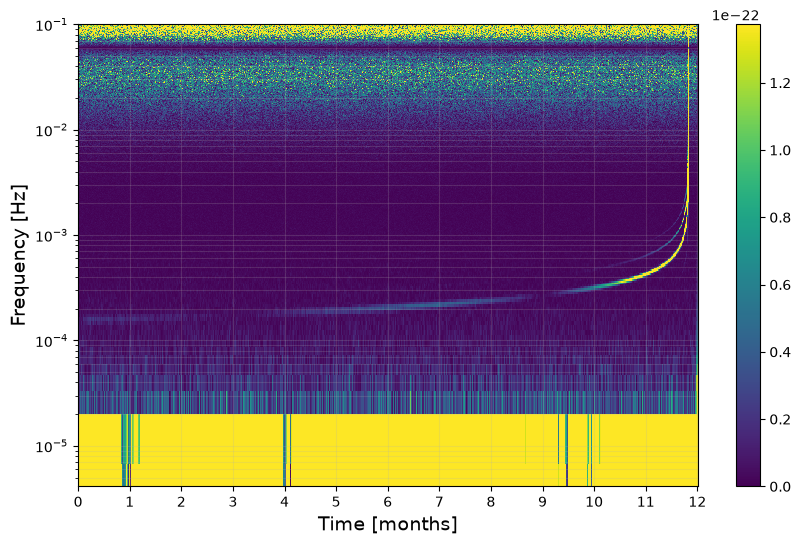

In [74]:
f_stft_noise, t_stft_noise, zxx_noise = sp.signal.stft(wave_time_domain_with_noise[1], fs=1/dt, nperseg=15000)
max_freq = 0.1
max_freq_idx = np.searchsorted(f_stft_noise, max_freq)
min_freq = 1e-4
min_freq_idx = np.searchsorted(f_stft_noise, min_freq)

t_months = t_stft_noise/(24*3600)/30.45428241


plt.figure(figsize=(10, 6))


fontsize_plots = 14
#plt.pcolormesh(t_months, f_stft_noise[min_freq_idx:max_freq_idx], np.abs(zxx_noise[min_freq_idx:max_freq_idx]), vmin=0, vmax= np.max(np.abs(zxx_noise[min_freq_idx:max_freq_idx]))/100, cmap='viridis')

plt.pcolormesh(t_months, f_stft_noise, np.abs(zxx_noise), vmin=0, vmax= np.max(np.abs(zxx_noise))/100, cmap='viridis')

### Add a grid with 20 vertical lines and 10 horizontal lines
plt.grid(True, which='both', alpha=0.2)
plt.xticks(np.arange(0, 13, 1)) 

plt.yscale('log')
plt.ylabel('Frequency [Hz]', fontsize=fontsize_plots)
plt.xlabel('Time [months]', fontsize=fontsize_plots)
plt.colorbar()

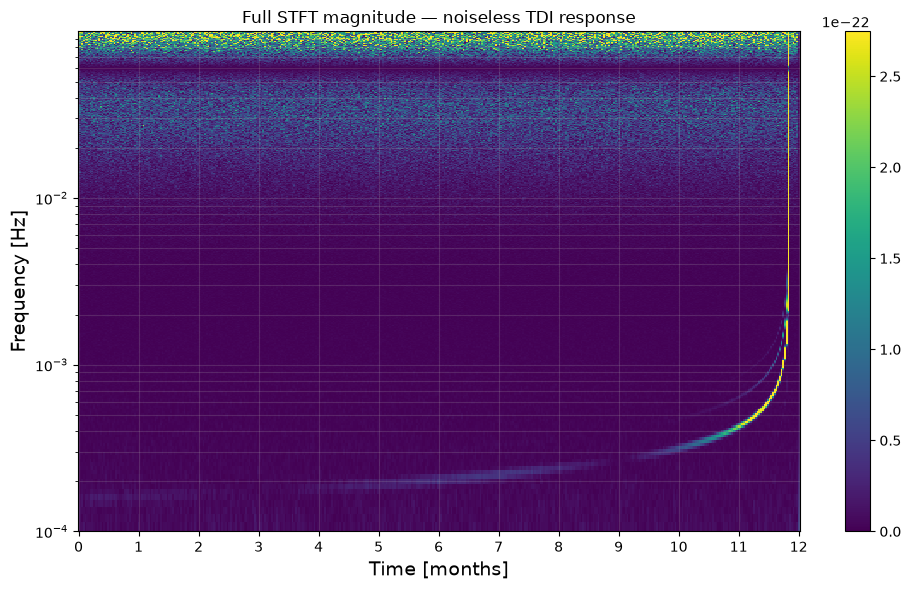

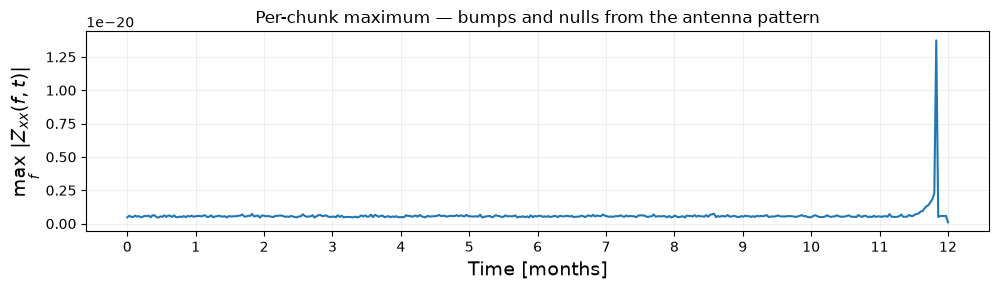

In [20]:
"""
STFT colormesh of the LISA TDI response — full-mesh version, tuned to
match the working plotting parameters (frequency crop, log y-axis,
vmax/50 clipping) rather than a generic LogNorm.

Story for the slides:
  Panel 1 (this fix): full |Zxx(f, t)| mesh over the whole LISA band,
    cropped to where the signal actually lives (<0.1 Hz) -> nulls and
    bumps are visible directly, tied to sky location via the antenna
    pattern.
  Panel 2: the per-chunk max trace -> this is the reduced view that
    originally caught your eye.
"""

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Inputs — replace with your actual noiseless TDI channel
# ------------------------------------------------------------------
# dt : sample spacing [s]
# wave_time_domain[1] : (N,) noiseless TDI response (e.g. E channel)

fontsize_plots = 14

f, t, Zxx = sp.signal.stft(
    wave_time_domain_with_noise[1], fs=1 / dt, nperseg=15000, noverlap=0
)

# Crop to where the LISA response actually has power — this is why
# "nothing above 0.1 Hz" was showing as empty/background-colored space
min_freq, max_freq = 1e-4, 0.1
min_freq_idx = np.searchsorted(f, min_freq)
max_freq_idx = np.searchsorted(f, max_freq)

f_crop = f[min_freq_idx:max_freq_idx]
mag_crop = np.abs(Zxx[min_freq_idx:max_freq_idx])   # full (f, t) magnitude, not reduced

t_months = t / (24 * 3600) / 30.45428241

# ------------------------------------------------------------------
# 2. Full colormesh — the fix: keep the whole (f, t) plane, cropped
#    and clipped so the nulls/bumps are visible against the noise floor
# ------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 6))

pcm = ax1.pcolormesh(
    t_months,
    f_crop,
    mag_crop,
    vmin=0,
    vmax=np.max(mag_crop) / 50,   # empirical clip so low-power regions aren't washed out purple
    cmap="viridis",
)

ax1.grid(True, which="both", alpha=0.2)
ax1.set_xticks(np.arange(0, 13, 1))
ax1.set_yscale("log")
ax1.set_ylabel("Frequency [Hz]", fontsize=fontsize_plots)
ax1.set_xlabel("Time [months]", fontsize=fontsize_plots)
ax1.set_title("Full STFT magnitude — noiseless TDI response")
fig1.colorbar(pcm, ax=ax1)

fig1.tight_layout()
fig1.savefig("stft_full_colormesh.png", dpi=200)

# ------------------------------------------------------------------
# 3. Per-chunk max trace — the reduced view that originally showed
#    the bumps and zeros and motivated the idea
# ------------------------------------------------------------------
max_per_chunk = mag_crop.max(axis=0)   # max over the cropped frequency band, per time chunk

fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.plot(t_months, max_per_chunk)
ax2.grid(True, alpha=0.2)
ax2.set_xticks(np.arange(0, 13, 1))
ax2.set_xlabel("Time [months]", fontsize=fontsize_plots)
ax2.set_ylabel(r"$\max_f\,|Z_{xx}(f,t)|$", fontsize=fontsize_plots)
ax2.set_title("Per-chunk maximum — bumps and nulls from the antenna pattern")

fig2.tight_layout()
fig2.savefig("stft_max_per_chunk.png", dpi=200)

plt.show()

# Code from Claude

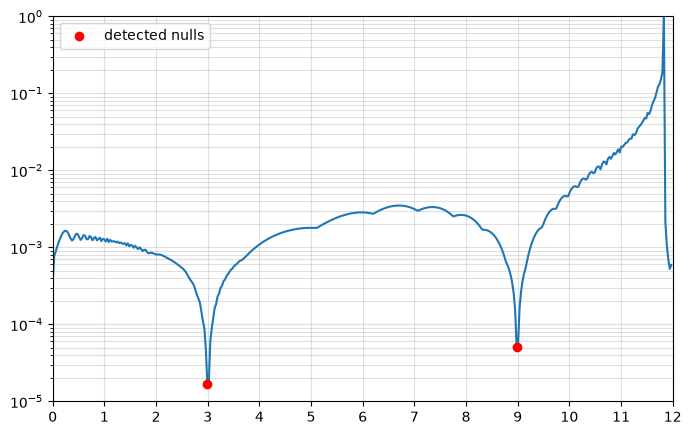

[2.99287411 8.97862233] [1.67827465e-05 5.06770699e-05]


In [21]:
import matplotlib.pyplot as plt

t_months, env = compute_stft_envelope(make_params())
null_t, null_d = find_nulls(t_months, env)

plt.figure(figsize=(8, 5))
plt.plot(t_months, env)
plt.scatter(null_t, null_d, color='red', zorder=5, label='detected nulls')
plt.yscale('log')
plt.ylim(1e-5, 1)
plt.xlim(0, 12)
plt.xticks(range(13))
plt.grid(True, which='both', alpha=0.4)
plt.legend()
plt.show()

print(null_t, null_d)

In [26]:
params_to_sweep = ["m1", "m2", "chi1z", "chi2z", "dist", "phi_ref", "inc", "psi", "lam", "beta"]

In [23]:
from antenna_pattern_utils import sweep_parameter, summarize_sweep_global_min
all_results = {}
summary = {}
for name in params_to_sweep:
    print(f"sweeping {name}...")
    r = sweep_parameter(name, n_points=7)
    all_results[name] = r
    summary[name] = summarize_sweep_global_min(r)

for name, s in summary.items():
    print(f"{name:8s}  Δt_min = {s['max_time_shift_months']:.4f} months   "
          f"Δdepth = {s['max_depth_shift_dex']:.3f} dex")

sweeping m1...
sweeping m2...
sweeping chi1z...
sweeping chi2z...
sweeping dist...
sweeping phi_ref...
sweeping inc...
sweeping psi...
sweeping lam...
sweeping beta...
m1        Δt_min = 0.0285 months   Δdepth = 0.340 dex
m2        Δt_min = 0.0285 months   Δdepth = 0.470 dex
chi1z     Δt_min = 0.0285 months   Δdepth = 0.204 dex
chi2z     Δt_min = 0.0285 months   Δdepth = 0.158 dex
dist      Δt_min = 0.0000 months   Δdepth = 0.000 dex
phi_ref   Δt_min = 0.0000 months   Δdepth = 0.056 dex
inc       Δt_min = 1.9382 months   Δdepth = 0.429 dex
psi       Δt_min = 0.0285 months   Δdepth = 0.133 dex
lam       Δt_min = 11.8575 months   Δdepth = 1.485 dex
beta      Δt_min = 5.9857 months   Δdepth = 1.939 dex


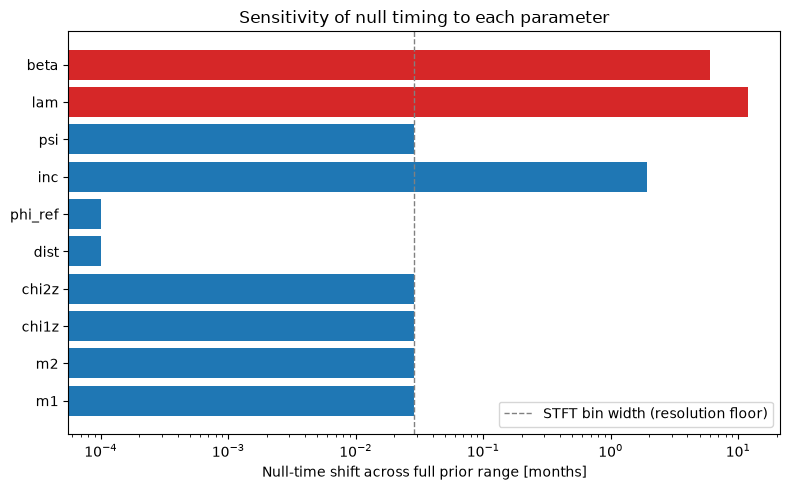

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

names = params_to_sweep
values = [max(summary[n]["max_time_shift_months"], 1e-4) for n in names]  # floor for log scale / zero dist case
colors = ['#d62728' if n in ("lam", "beta") else '#1f77b4' for n in names]

y_pos = np.arange(len(names))
ax.barh(y_pos, values, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xscale('log')
ax.set_xlabel('Null-time shift across full prior range [months]')
ax.axvline(0.0285, color='gray', linestyle='--', linewidth=1, label='STFT bin width (resolution floor)')
ax.legend(loc='lower right')
ax.set_title('Sensitivity of null timing to each parameter')
plt.tight_layout()
plt.show()

In [28]:
params_to_sweep_new = ["m1", "m2", "chi1z", "chi2z", "dist_Gpc", "phi_ref", "inc", "psi", "lam", "beta"]

params_to_sweep_new[4]

'dist_Gpc'

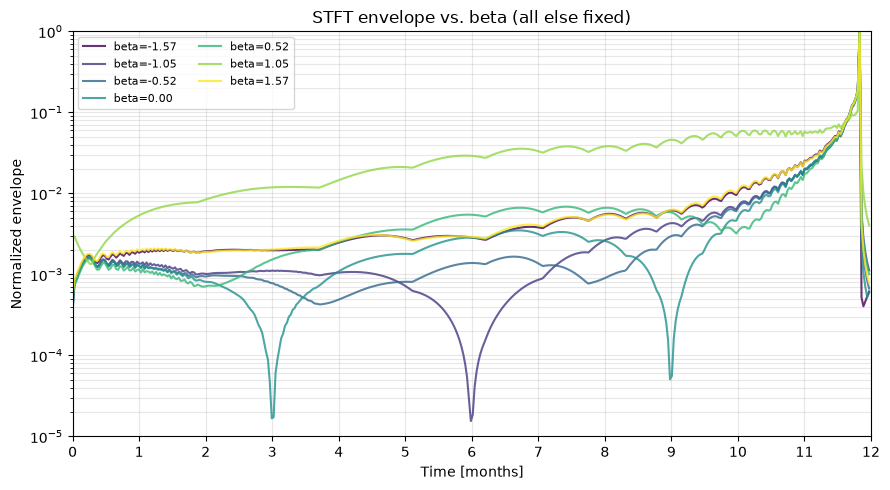

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

parameter_to_overlay = params_to_sweep[9]

parameter_results = all_results[parameter_to_overlay]
parameter_values = np.linspace(*PRIORS[parameter_to_overlay], len(parameter_results))  # same values sweep_parameter used

cmap = plt.cm.viridis
for val, r in zip(parameter_values, parameter_results):
    color = cmap((val - parameter_values.min()) / (parameter_values.max() - parameter_values.min()))
    ax.plot(r["t_months"], r["envelope"], color=color, label=f"{parameter_to_overlay}={val:.2f}", alpha=0.8)

ax.set_yscale('log')
ax.set_ylim(1e-5, 1)
ax.set_xlim(0, 12)
ax.set_xticks(range(13))
ax.set_xlabel('Time [months]')
ax.set_ylabel('Normalized envelope')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, ncol=2)
ax.set_title(f'STFT envelope vs. {parameter_to_overlay} (all else fixed)')
plt.tight_layout()
plt.show()

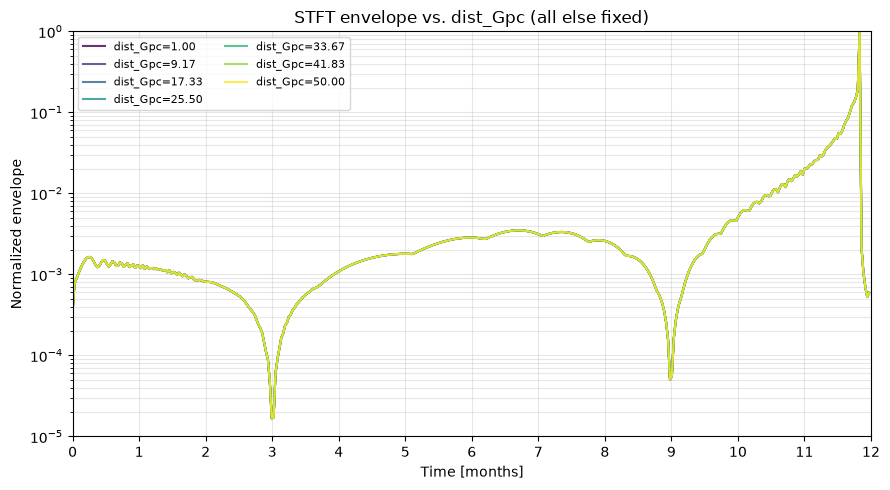

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

parameter_to_overlay = params_to_sweep_new[4]

parameter_results = all_results[params_to_sweep[4]]
parameter_values = np.linspace(*PRIORS[parameter_to_overlay], len(parameter_results))  # same values sweep_parameter used

cmap = plt.cm.viridis
for val, r in zip(parameter_values, parameter_results):
    color = cmap((val - parameter_values.min()) / (parameter_values.max() - parameter_values.min()))
    ax.plot(r["t_months"], r["envelope"], color=color, label=f"{parameter_to_overlay}={val:.2f}", alpha=0.8)

ax.set_yscale('log')
ax.set_ylim(1e-5, 1)
ax.set_xlim(0, 12)
ax.set_xticks(range(13))
ax.set_xlabel('Time [months]')
ax.set_ylabel('Normalized envelope')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, ncol=2)
ax.set_title(f'STFT envelope vs. {parameter_to_overlay} (all else fixed)')
plt.tight_layout()
plt.show()

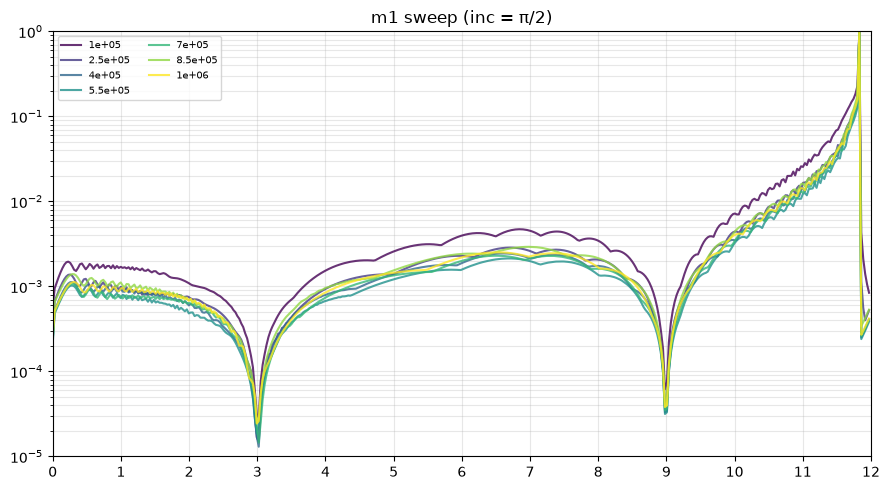

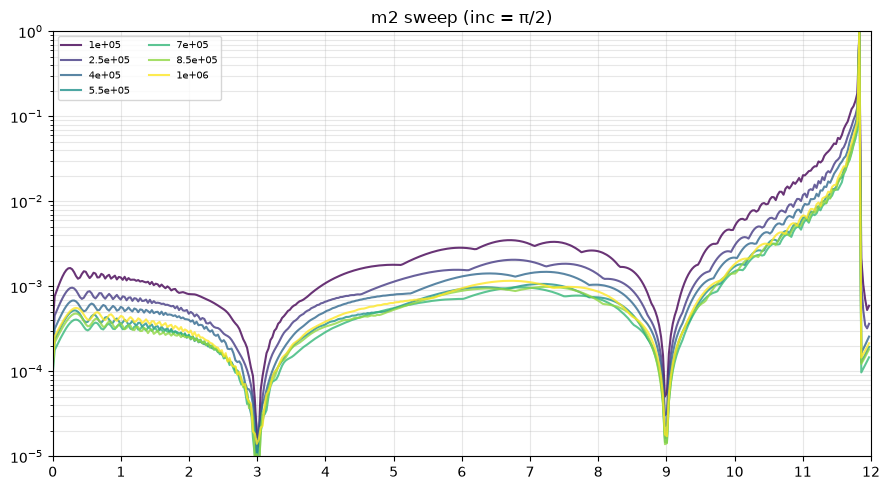

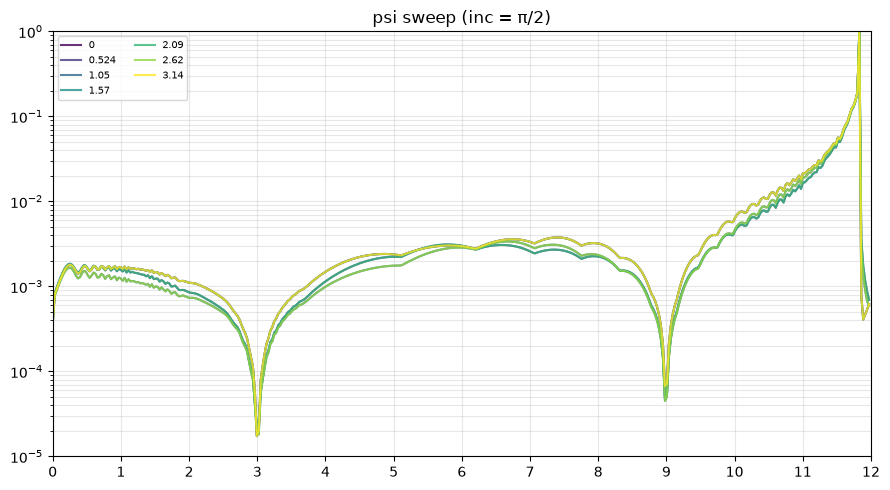

In [31]:
def plot_sweep_overlay(results, values, title):
    fig, ax = plt.subplots(figsize=(9, 5))
    cmap = plt.cm.viridis
    for val, r in zip(values, results):
        color = cmap((val - values.min()) / (values.max() - values.min()))
        ax.plot(r["t_months"], r["envelope"], color=color, alpha=0.8, label=f"{val:.3g}")
    ax.set_yscale('log'); ax.set_ylim(1e-5, 1)
    ax.set_xlim(0, 12); ax.set_xticks(range(13))
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
    ax.set_title(title)
    plt.tight_layout(); plt.show()

for name in ["m1", "m2", "psi"]:
    r = sweep_parameter(name, n_points=7)   # inc=π/2 now baked into DEFAULT_PARAMS
    vals = np.linspace(*PRIORS[name if name != "psi" else "psi"], 7)
    plot_sweep_overlay(r, vals, f"{name} sweep (inc = π/2)")

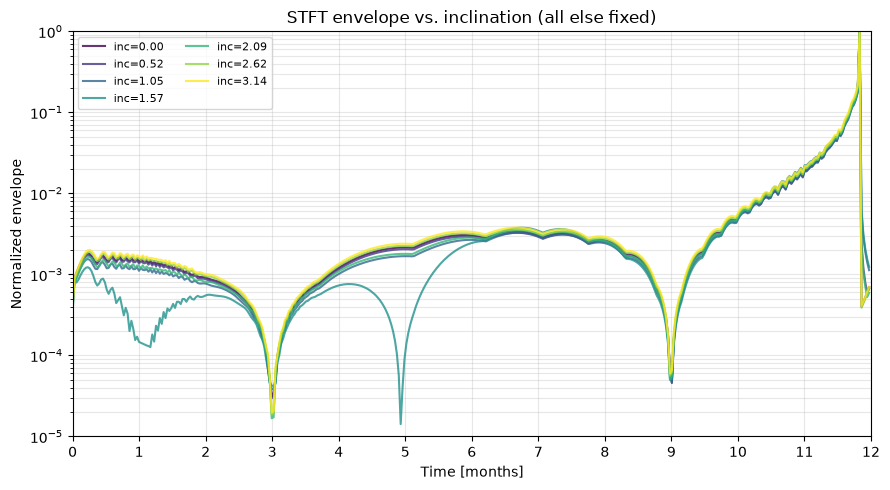

In [32]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))

inc_results = all_results["inc"]
inc_values = np.linspace(*PRIORS["inc"], len(inc_results))  # same values sweep_parameter used

cmap = plt.cm.viridis
for val, r in zip(inc_values, inc_results):
    color = cmap((val - inc_values.min()) / (inc_values.max() - inc_values.min()))
    ax.plot(r["t_months"], r["envelope"], color=color, label=f"inc={val:.2f}", alpha=0.8)

ax.set_yscale('log')
ax.set_ylim(1e-5, 1)
ax.set_xlim(0, 12)
ax.set_xticks(range(13))
ax.set_xlabel('Time [months]')
ax.set_ylabel('Normalized envelope')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, ncol=2)
ax.set_title('STFT envelope vs. inclination (all else fixed)')
plt.tight_layout()
plt.show()

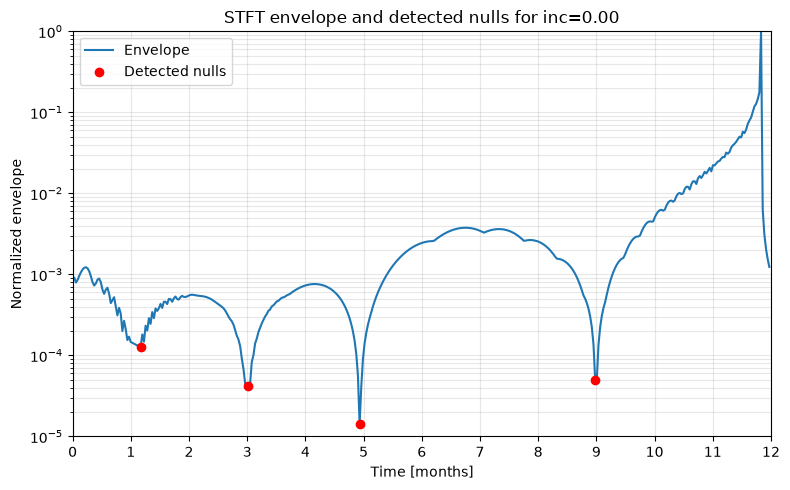

In [33]:
# Plot only for the 1st inc value to illustrate the nulls
first_inc_result = inc_results[3]
plt.figure(figsize=(8, 5))
plt.plot(first_inc_result["t_months"], first_inc_result["envelope"], label='Envelope')
plt.scatter(first_inc_result["null_times"], first_inc_result["null_depths"], color='red', zorder=5, label='Detected nulls')
plt.yscale('log')
plt.ylim(1e-5, 1)
plt.xlim(0, 12)
plt.xticks(range(13))
plt.xlabel('Time [months]')
plt.ylabel('Normalized envelope')
plt.title(f'STFT envelope and detected nulls for inc={inc_values[0]:.2f}')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

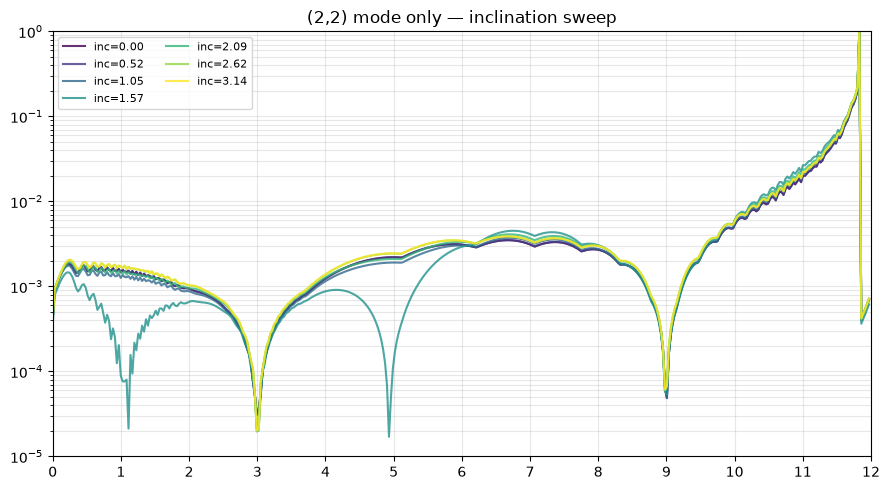

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Same inc sweep, but restricted to the (2,2) mode only
inc_results_22 = sweep_parameter("inc", n_points=7, envelope_kwargs={"modes": [(2, 2)]})

fig, ax = plt.subplots(figsize=(9, 5))
inc_values = np.linspace(*PRIORS["inc"], len(inc_results_22))
cmap = plt.cm.viridis
for val, r in zip(inc_values, inc_results_22):
    color = cmap((val - inc_values.min()) / (inc_values.max() - inc_values.min()))
    ax.plot(r["t_months"], r["envelope"], color=color, label=f"inc={val:.2f}", alpha=0.8)

ax.set_yscale('log')
ax.set_ylim(1e-5, 1)
ax.set_xlim(0, 12)
ax.set_xticks(range(13))
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, ncol=2)
ax.set_title('(2,2) mode only — inclination sweep')
plt.tight_layout()
plt.show()

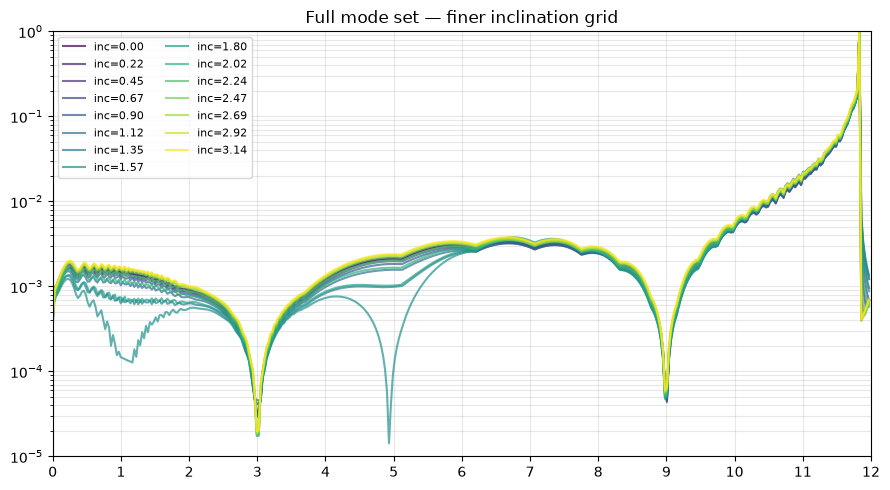

In [35]:
inc_fine_results = sweep_parameter(
    "inc", n_points=15,
    base_overrides={},  # full mode set, finer grid
)
inc_fine_values = np.linspace(*PRIORS["inc"], 15)

fig, ax = plt.subplots(figsize=(9, 5))
for val, r in zip(inc_fine_values, inc_fine_results):
    color = cmap((val - inc_fine_values.min()) / (inc_fine_values.max() - inc_fine_values.min()))
    ax.plot(r["t_months"], r["envelope"], color=color, alpha=0.7, label=f"inc={val:.2f}")
ax.set_yscale('log')
ax.set_ylim(1e-5, 1)
ax.set_xlim(0, 12)
ax.set_xticks(range(13))
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, ncol=2)
ax.set_title('Full mode set — finer inclination grid')
plt.tight_layout()
plt.show()

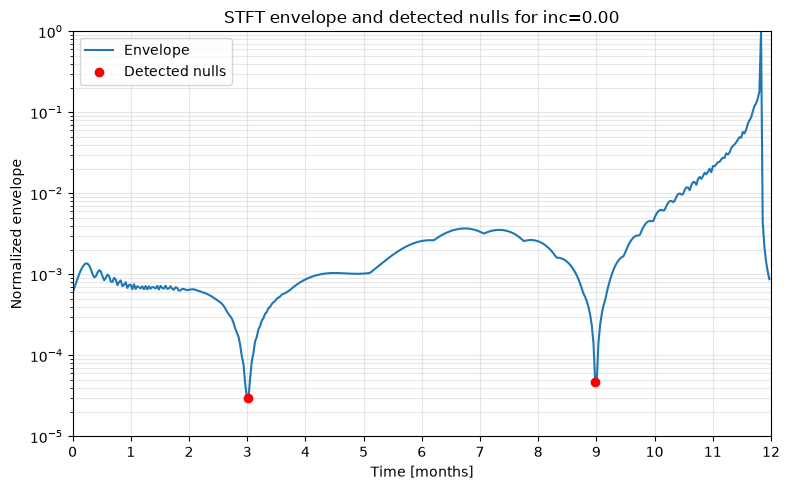

In [36]:
# Plot only for the 1st inc value to illustrate the nulls
first_inc_fine_result = inc_fine_results[8]
plt.figure(figsize=(8, 5))
plt.plot(first_inc_fine_result["t_months"], first_inc_fine_result["envelope"], label='Envelope')
plt.scatter(first_inc_fine_result["null_times"], first_inc_fine_result["null_depths"], color='red', zorder=5, label='Detected nulls')
plt.yscale('log')
plt.ylim(1e-5, 1)
plt.xlim(0, 12)
plt.xticks(range(13))
plt.xlabel('Time [months]')
plt.ylabel('Normalized envelope')
plt.title(f'STFT envelope and detected nulls for inc={inc_fine_values[0]:.2f}')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

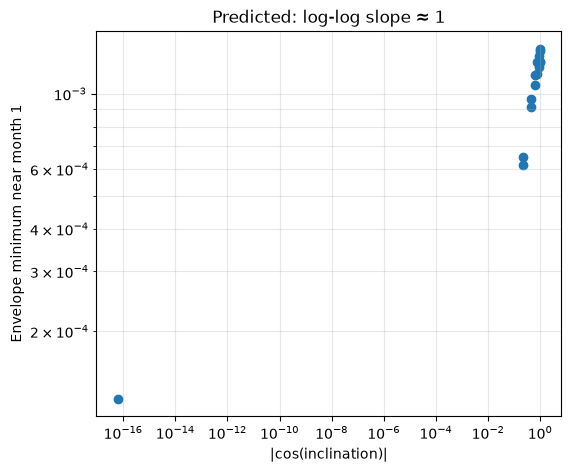

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def local_min_in_window(t_months, envelope, window):
    mask = (t_months >= window[0]) & (t_months <= window[1])
    return envelope[mask].min()

t_window = (0.5, 1.5)  # around the month-1 dip
depths_near_1mo = np.array([
    local_min_in_window(r["t_months"], r["envelope"], t_window) for r in inc_fine_results
])
cos_inc = np.abs(np.cos(inc_fine_values))

plt.figure(figsize=(6, 5))
plt.scatter(cos_inc, depths_near_1mo)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('|cos(inclination)|')
plt.ylabel('Envelope minimum near month 1')
plt.grid(alpha=0.3, which='both')
plt.title('Predicted: log-log slope ≈ 1')
plt.show()

sweeping m1...
sweeping m2...
sweeping chi1z...
sweeping chi2z...
sweeping dist...
sweeping phi_ref...
sweeping inc...
sweeping psi...
sweeping lam...
sweeping beta...
m1        Δt_matched = 0.0285 months   Δdepth = 0.291 dex   (mismatched null count: 0/7)
m2        Δt_matched = 0.0285 months   Δdepth = 0.491 dex   (mismatched null count: 0/7)
chi1z     Δt_matched = 0.0285 months   Δdepth = 0.204 dex   (mismatched null count: 0/7)
chi2z     Δt_matched = 0.0285 months   Δdepth = 0.141 dex   (mismatched null count: 0/7)
dist      Δt_matched = 0.0000 months   Δdepth = 0.000 dex   (mismatched null count: 0/7)
phi_ref   Δt_matched = 0.0000 months   Δdepth = 0.044 dex   (mismatched null count: 0/7)
inc       Δt_matched = 1.9382 months   Δdepth = 0.878 dex   (mismatched null count: 6/7)
psi       Δt_matched = 0.0285 months   Δdepth = 0.175 dex   (mismatched null count: 0/7)
lam       Δt_matched = 0.0285 months   Δdepth = 0.178 dex   (mismatched null count: 4/7)
beta      Δt_matched = 5.2447 m

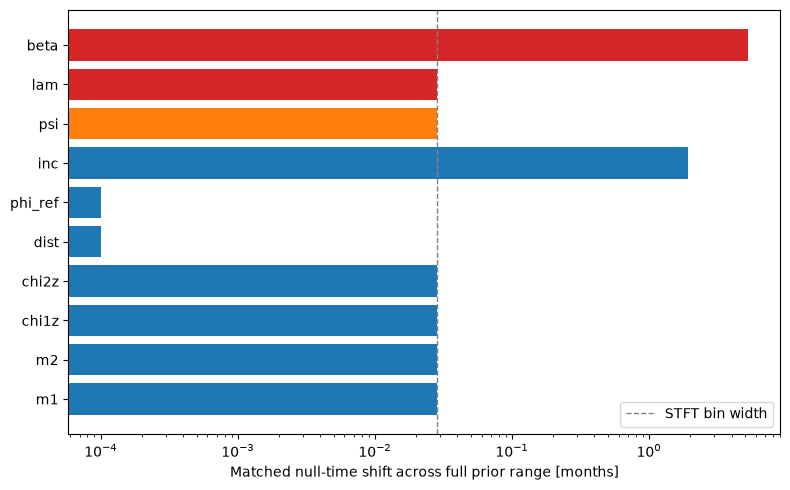

In [38]:
from antenna_pattern_utils import summarize_sweep_matched
import numpy as np
import matplotlib.pyplot as plt

summary_matched = {}
for name in params_to_sweep:
    print(f"sweeping {name}...")
    r = sweep_parameter(name, n_points=7)
    summary_matched[name] = summarize_sweep_matched(r)

for name, s in summary_matched.items():
    print(f"{name:8s}  Δt_matched = {s['max_time_shift_months']:.4f} months   "
          f"Δdepth = {s['max_depth_shift_dex']:.3f} dex   "
          f"(mismatched null count: {s['n_mismatch']}/{s['n_total']})")

fig, ax = plt.subplots(figsize=(8, 5))
values = [max(summary_matched[n]["max_time_shift_months"], 1e-4) for n in params_to_sweep]
colors = ['#d62728' if n in ("lam", "beta") else '#ff7f0e' if n == "psi" else '#1f77b4'
          for n in params_to_sweep]
ax.barh(np.arange(len(params_to_sweep)), values, color=colors)
ax.set_yticks(np.arange(len(params_to_sweep)))
ax.set_yticklabels(params_to_sweep)
ax.set_xscale('log')
ax.set_xlabel('Matched null-time shift across full prior range [months]')
ax.axvline(0.0285, color='gray', linestyle='--', linewidth=1, label='STFT bin width')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

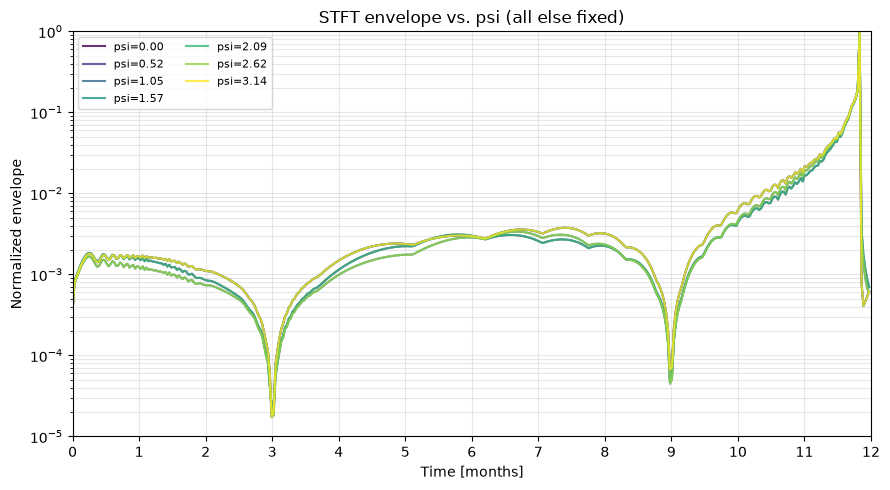

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

parameter_to_overlay = params_to_sweep[7]

parameter_results = all_results[parameter_to_overlay]
parameter_values = np.linspace(*PRIORS[parameter_to_overlay], len(parameter_results))  # same values sweep_parameter used

cmap = plt.cm.viridis
for val, r in zip(parameter_values, parameter_results):
    color = cmap((val - parameter_values.min()) / (parameter_values.max() - parameter_values.min()))
    ax.plot(r["t_months"], r["envelope"], color=color, label=f"{parameter_to_overlay}={val:.2f}", alpha=0.8)

ax.set_yscale('log')
ax.set_ylim(1e-5, 1)
ax.set_xlim(0, 12)
ax.set_xticks(range(13))
ax.set_xlabel('Time [months]')
ax.set_ylabel('Normalized envelope')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, ncol=2)
ax.set_title(f'STFT envelope vs. {parameter_to_overlay} (all else fixed)')
plt.tight_layout()
plt.show()